# Poisson Regression Model 


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import poisson

from lib import plots
from lib.scores import max_expected_reward_guesses, to_predictions_df
from lib.utils import cross_validate_model

Goal: 
- Model the joint distribution of $X_h$ and $X_a$, representing the goals of the home and away team respectively
- Derive the prediction that maximizes the expected Kicktipp score under this distribution

Poisson Regression Model:
- The number of goals scored by each team $X_h$ and $X_a$ is assumed to follow independent Poisson distributions
- Expected goals $\lambda_h$, $\lambda_a$ for home and away teams are predicted using team-specific parameters and a home advantage term
- Team-specific parameters contain attack and defense strengths
- Model parameters are estimated by maximizing the likelihood of observed match results, subject to identifiability constraints

In [ ]:
class PoissonModel:
    def __init__(self, max_goals=4):
        self.max_goals = max_goals
        self.teams_ = None
        self.n_teams_ = None
        self.attack_params_ = None
        self.defense_params_ = None
        self.home_advantage_ = None

    def _encode_teams(self, df_matches):
        """Create team encoding and return match data with team indices."""
        all_teams = df_matches["home"].unique()
        self.teams_ = {team: idx for idx, team in enumerate(all_teams)}
        self.n_teams_ = len(all_teams)

        # Convert team names to indices
        home_idx = df_matches["home"].map(self.teams_).values
        away_idx = df_matches["away"].map(self.teams_).values
        home_goals = df_matches["home_goals"].values
        away_goals = df_matches["away_goals"].values

        return home_idx, away_idx, home_goals, away_goals

    def _negative_log_likelihood(
        self, params, home_idx, away_idx, home_goals, away_goals
    ):
        """Compute negative log-likelihood for the Poisson model."""
        # Extract parameters
        attack_params = params[: self.n_teams_]
        defense_params = params[self.n_teams_ : 2 * self.n_teams_]
        home_advantage = params[2 * self.n_teams_]

        # Compute expected goals using linear predictors
        # log(lambda_home) = attack_home - defense_away + home_advantage
        # log(lambda_away) = attack_away - defense_home
        lambda_home = np.exp(
            attack_params[home_idx] - defense_params[away_idx] + home_advantage
        )
        lambda_away = np.exp(attack_params[away_idx] - defense_params[home_idx])

        # Compute log-likelihood
        # For Poisson: log P(k; λ) = k*log(λ) - λ - log(k!)
        # We ignore the log(k!) term as it doesn't affect optimization
        log_likelihood_home = home_goals * np.log(lambda_home) - lambda_home
        log_likelihood_away = away_goals * np.log(lambda_away) - lambda_away

        total_log_likelihood = np.sum(log_likelihood_home + log_likelihood_away)

        return -total_log_likelihood  # Return negative for minimization

    def _constraint_sum_to_zero_attack(self, params):
        """Constraint: sum of attack parameters = 0"""
        return np.sum(params[: self.n_teams_])

    def _constraint_sum_to_zero_defense(self, params):
        """Constraint: sum of defense parameters = 0"""
        return np.sum(params[self.n_teams_ : 2 * self.n_teams_])

    def fit(self, df_matches):
        """Fit the Poisson model to match data."""
        # Encode teams and extract match data
        home_idx, away_idx, home_goals, away_goals = self._encode_teams(df_matches)

        # Initialize parameters
        # Start with small random values around 0
        n_params = 2 * self.n_teams_ + 1  # attack + defense + home_advantage
        initial_params = np.random.normal(0, 0.01, n_params)

        # Set up constraints for identifiability
        constraints = [
            {"type": "eq", "fun": self._constraint_sum_to_zero_attack},
            {"type": "eq", "fun": self._constraint_sum_to_zero_defense},
        ]

        # Add bounds to prevent extreme values
        bounds = []
        for _i in range(2 * self.n_teams_):  # attack and defense params
            bounds.append((-5, 5))  # Reasonable bounds
        bounds.append((-2, 2))  # home advantage bound

        # Optimize using scipy
        result = minimize(
            self._negative_log_likelihood,
            initial_params,
            args=(home_idx, away_idx, home_goals, away_goals),
            bounds=bounds,
            options={"maxiter": 1000},
            constraints=constraints,
        )

        if not result.success:
            print(f"Optimization failed: {result.message}")

        # Store fitted parameters
        params = result.x
        self.attack_params_ = params[: self.n_teams_]
        self.defense_params_ = params[self.n_teams_ : 2 * self.n_teams_]
        self.home_advantage_ = params[2 * self.n_teams_]

        return self

    def _predict_lambda(self, df_matches):
        """Predict expected goals (lambda parameters) for matches."""
        if self.teams_ is None:
            raise ValueError("Model must be fitted before making predictions")

        # Convert team names to indices
        home_idx = df_matches["home"].map(self.teams_).values
        away_idx = df_matches["away"].map(self.teams_).values

        # Handle unknown teams by using parameters of the weakest team
        unknown_home = np.isnan(home_idx)
        unknown_away = np.isnan(away_idx)

        if np.any(unknown_home) or np.any(unknown_away):
            # Find index of weakest team (lowest attack)
            weakest_team_idx = self.attack_params_.argmin()

            home_idx = np.where(unknown_home, weakest_team_idx, home_idx).astype(int)
            away_idx = np.where(unknown_away, weakest_team_idx, away_idx).astype(int)

        # Compute expected goals
        lambda_home = np.exp(
            self.attack_params_[home_idx]
            - self.defense_params_[away_idx]
            + self.home_advantage_
        )
        lambda_away = np.exp(
            self.attack_params_[away_idx] - self.defense_params_[home_idx]
        )

        return lambda_home, lambda_away

    def predict_proba(self, df_matches):
        """Predict probability matrices for scorelines."""
        lambda_home, lambda_away = self._predict_lambda(df_matches)

        n_matches = len(df_matches)
        probabilities = np.zeros((n_matches, self.max_goals + 1, self.max_goals + 1))

        for i in range(n_matches):
            for home_goals in range(self.max_goals + 1):
                for away_goals in range(self.max_goals + 1):
                    # Probability = P(home_goals) * P(away_goals) due to independence
                    prob_home = (
                        poisson.pmf(home_goals, lambda_home[i])
                        if home_goals < self.max_goals
                        else poisson.sf(self.max_goals - 1, lambda_home[i])
                    )
                    prob_away = (
                        poisson.pmf(away_goals, lambda_away[i])
                        if away_goals < self.max_goals
                        else poisson.sf(self.max_goals - 1, lambda_away[i])
                    )
                    probabilities[i, home_goals, away_goals] = prob_home * prob_away

        # Normalize to ensure each match probability matrix sums to 1
        probabilities = probabilities / probabilities.sum(axis=(1, 2), keepdims=True)

        return probabilities

    def predict(self, df_matches):
        """Predict optimal scorelines to maximize expected Kicktipp points."""
        probabilities = self.predict_proba(df_matches)
        guesses = max_expected_reward_guesses(probabilities, max_goals=self.max_goals)
        return guesses

    def get_team_params(self):
        team_names = list(self.teams_.keys())
        return pd.DataFrame(
            {
                "team": team_names,
                "attack": self.attack_params_,
                "defense": self.defense_params_,
            }
        )

## Training the model

In [13]:
# Load data
df_matches = pd.read_pickle("data/matches.pkl")
df_matches = df_matches[df_matches["season"] < 2025]  # Use only past seasons
df_matches = df_matches[df_matches["league"] == "bl1"]
df_train = df_matches[df_matches["season"].isin([2021, 2022, 2023])]
df_test = df_matches[df_matches["season"] == 2024]

In [14]:
poisson_model = PoissonModel(max_goals=4)
poisson_model.fit(df_train)

print(f"Home advantage: {poisson_model.home_advantage_:.3f}")

Home advantage: 0.445


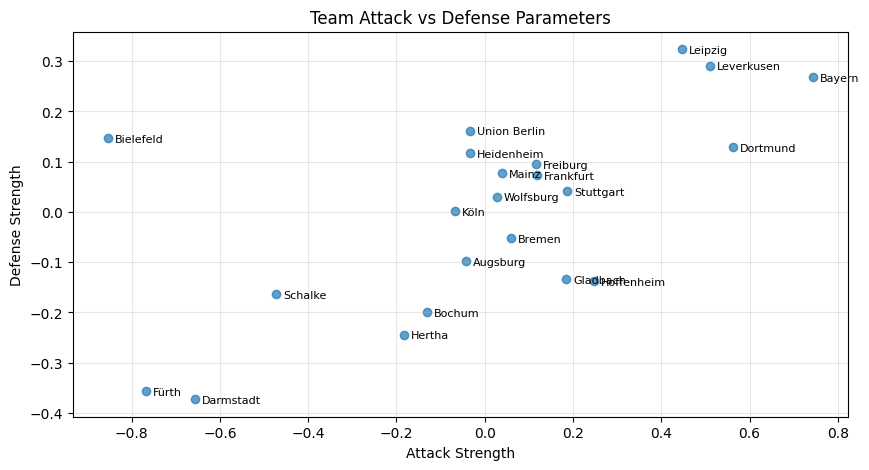

In [15]:
plots.plot_team_strenghts(poisson_model.get_team_params())

**Key insights:**
- Teams closer to the top-right are generally stronger overall
- Zero-sum constraints mean parameters are relative - a team with attack strength 0.2 attacks $\exp(0.2) \approx 1.22$ times better than average

In [ ]:
poisson_test_guesses = poisson_model.predict(df_test)
df_predictions = to_predictions_df(df_test, poisson_test_guesses)

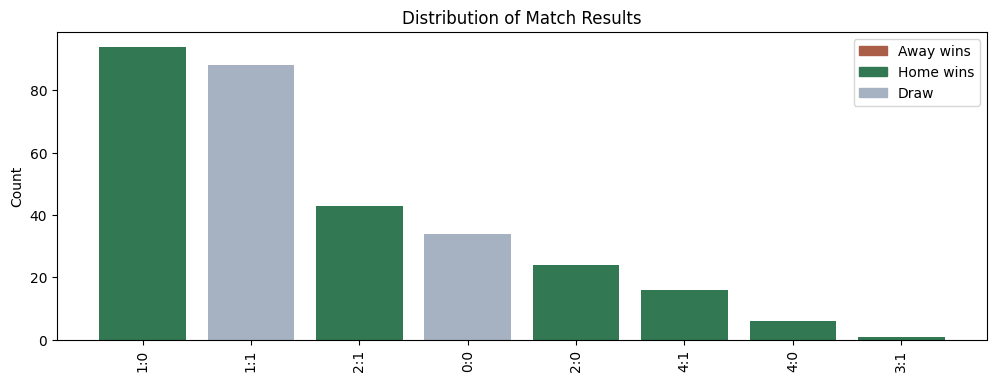

In [17]:
plots.scoreline_distribution(
    df_predictions, top_k=10, goals_col=("home_goals_pred", "away_goals_pred")
)

**Key insights**:
- Model never bets on away team
- Model most often predicts 1:0 followed by 1:1

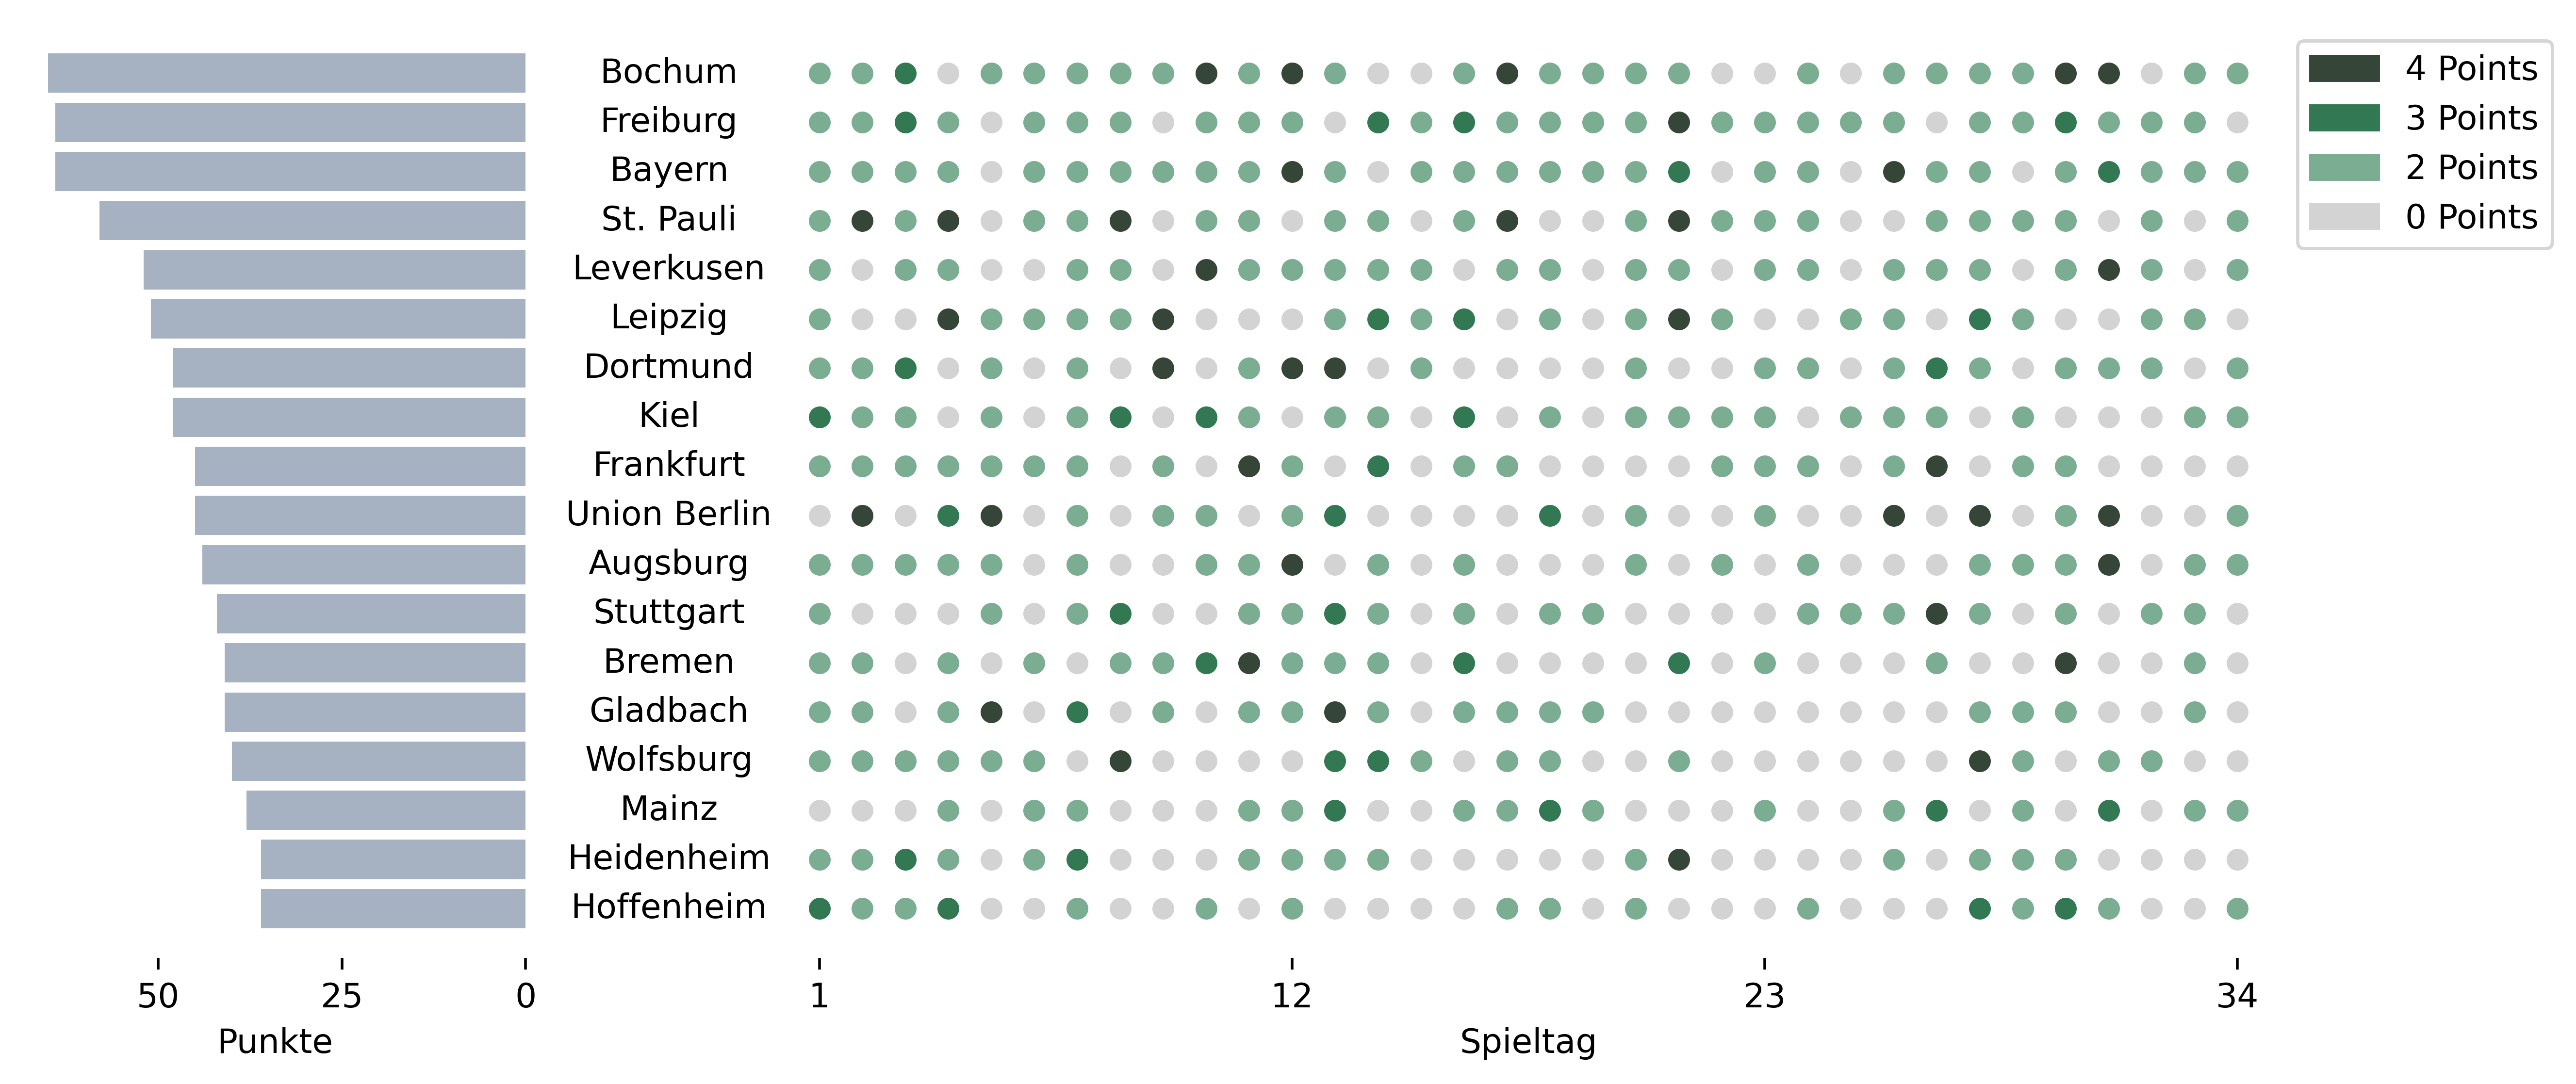

In [18]:
plots.kicktipp_score_summary(df_predictions)

**Key insights**:
- Model makes most points with teams that are either very strong, such as Bayern, or very weak, such as Bochum
- Model struggles with mid-teams, such as Hoffenheim

## Cross-validation

In [19]:
poisson_cv_result = cross_validate_model(PoissonModel(max_goals=4), df_matches)
poisson_cv_result.print_summary()

Mean score: 455.3 ± 19.0
Individual scores: [458, 467, 443, 476, 434, 414, 457, 464, 423, 466, 477, 476, 460, 459]


## Final predictions

In [20]:
df_matches = pd.read_pickle("data/matches.pkl")
df_matches = df_matches[df_matches["league"] == "bl1"]

year = 2025
horizon = 6
df_train = df_matches[
    (df_matches["season"] < year) & (df_matches["season"] >= year - horizon)
]
df_test = df_matches[df_matches["season"] == year]
poisson_model = PoissonModel(max_goals=4)
poisson_model.fit(df_train)
poisson_test_guesses = poisson_model.predict(df_test)
df_predictions = df_test.copy()
df_predictions["home_goals_pred"] = poisson_test_guesses[:, 0]
df_predictions["away_goals_pred"] = poisson_test_guesses[:, 1]
df_predictions.to_pickle(f"data/predictions_poisson_{year}.pkl")